#

<div align=center>
<img src="https://uol.unifor.br/acesso/app/autenticacao/assets/img/logos/icon-unifor.svg" width=45 height=45>

<br><br>
<font size=5 color='black'><strong>MBA Ciência de dados:</strong> Estatística descritiva

<strong>Projeto:</strong> Titanic

<strong>Autoria:</strong> Heitor Teixeira

</div>

## <font color=darkblue> 1 - Imports e declaração de constantes e funções

### <font color=steelblue> 1.1 - Imports

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import numpy as np

### <font color=steelblue> 1.2 - Constantes

Declarar constantes em uma unica celula facilita a manutenção de notebooks longos.<br>Alguns benefícios:
1. Melhorar a legibilidade do codigo
2. As constantes podem ser esquema de cores para padronizar sempre as mesmas cores para determinadas classes, paths de arquivos e datasets e etc.
3. posso modifica-las apenas aqui e servir para o codigo inteiro


In [43]:
# dataset do professor
PATH_ELEICOES = "datasets/eleicoes.csv"

# arquivos auxiliares do TSE para enriquecimento
PATH_CANDIDATOS = "datasets/extras/consulta_cand_2014_BRASIL.csv"
PATH_DESPESAS = "datasets/extras/despesas_candidatos_2014_brasil.txt"

PATH_DATASET_ENRIQUECIDO = "datasets/extras/eleicoes_enriquecido.csv"
PATH_FORNECEDORES = "datasets/extras/fornecedores_deputados.csv"

# paleta de cores para deixar os graficos padronizados
CORES = [
    "#4878D0",  # 0 azul
    "#EE854A",  # 1 laranja
    "#6ACC64",  # 2 verde
    "#D65F5F",  # 3 vermelho
    "#956CB4",  # 4 roxo
    "#7B2D8B",  # 5 purple
    "#4169E1",  # 6 royalblue
    "#FF8C00",  # 7 darkorange
    "#000000",  # 8 preto
    "#006400",  # 9 darkgreen
    "#008080",  # 10 teal
]

# tamanho padrao dos graficos
FIGSIZE = (12, 6)

# mapeamento de colunas: dataset original do professor
MAP_COLUMNS_ELEICOES = {
    "State": "Estado",
    "Candidate Number": "Numero Candidato",
    "Money (R$ Reais)": "Gasto",
    "Votes": "Votos",
}

# mapeamento de colunas: prestacao de contas TSE (despesas)
MAP_COLUMNS_DESPESAS = {
    "UF": "Estado",
    "Número candidato": "Numero Candidato",
    "Nome candidato": "Nome",
    "Sigla Partido": "Partido",
    "CPF do candidato": "CPF",
}

# mapeamento de colunas: cadastro oficial de candidatos TSE
MAP_COLUMNS_CANDIDATOS = {
    "SG_UF": "Estado",
    "NR_CANDIDATO": "Numero Candidato",
    "DS_SIT_TOT_TURNO": "Situacao",
    "DS_GENERO": "Genero",
    "DS_GRAU_INSTRUCAO": "Escolaridade",
    "DS_ESTADO_CIVIL": "Estado Civil",
    "DS_COR_RACA": "Raca",
    "DT_NASCIMENTO": "Dt Nascimento",
}

# mapeamento de situacao eleitoral para resultado consolidado
SITUACAO_MAP = {
    "ELEITO POR QP": "Eleito",
    "ELEITO POR MÉDIA": "Eleito",
    "SUPLENTE": "Suplente",
    "NÃO ELEITO": "Não Eleito",
}

### <font color=steelblue> 1.3 - Funções

**`plot_gasto_vs_votos`:** o scatter de gasto vs votos por situação eleitoral é um gráfico complexo: 
- 3 grupos de pontos
- 4 linhas verticais de referência com estilos distintos 
- 2 linhas horizontais de votos mínimos 
- escala log nos dois eixos. 
- salvar imagem com nomeclatura diferente para cada estado ou agrupamento de estados.

reproduzir esse bloco para cada estado seria impraticável. a função encapsula toda essa lógica e aceita um filtro de estados, permitindo gerar o mesmo gráfico para o brasil inteiro, um único estado ou qualquer subconjunto.

**`tabela_gasto_vs_votos`:** complementa o scatter com os valores numéricos agregados por resultado eleitoral. o título da tabela é passado como argumento pois a numeração depende do contexto onde é chamada.

In [44]:
def plot_gasto_vs_votos(df, estados=None):
    """
    Args:
        df      : DataFrame — eleicoes_enriquecido ou qualquer subconjunto
        estados : list[str] ou None — ex: ['SP'], ['SP', 'RJ']. None = todos os estados
    """
    data = df.copy()

    if estados is not None:
        data = data[data["Estado"].isin(estados)]

    mask = (
        (data["Gasto"] > 0)
        & (data["Votos"] > 0)
        & data["Situacao"].isin(SITUACAO_MAP)
    )
    data = data[mask].copy()
    data["Resultado"] = data["Situacao"].map(SITUACAO_MAP)

    cores_resultado = {"Eleito": CORES[2], "Suplente": CORES[1], "Não Eleito": CORES[3]}

    eleitos_gasto = data[data["Resultado"] == "Eleito"]["Gasto"]

    refs_verticais = {
        "Mín eleitos":     (eleitos_gasto.min(),   CORES[5], (4, 2)),
        "Mediana eleitos": (eleitos_gasto.median(), CORES[6], (8, 4)),
        "Média eleitos":   (eleitos_gasto.mean(),   CORES[7], (6, 3)),
        "Máx eleitos":     (eleitos_gasto.max(),    CORES[8], (2, 2)),
    }

    min_votos_media = data[data["Situacao"] == "ELEITO POR MÉDIA"]["Votos"].min()
    min_votos_qp    = data[data["Situacao"] == "ELEITO POR QP"]["Votos"].min()

    titulo_extra = f" — {', '.join(estados)}" if estados else ""
    nome_arquivo = "gasto_vs_votos" + ("_" + "_".join(estados) if estados else "")

    fig, ax = plt.subplots(figsize=(11, 7))

    for resultado, grupo in data.groupby("Resultado"):
        ax.scatter(
            grupo["Gasto"],
            grupo["Votos"],
            c=cores_resultado[resultado],
            label=f"{resultado} (n={len(grupo)})",
            alpha=0.4,
            s=18,
            edgecolors="none",
        )

    for label, (valor, cor, dash) in refs_verticais.items():
        ax.axvline(valor, color=cor, linestyle="--", dashes=dash, label=f"{label}: R$ {valor:,.0f}")

    if not pd.isna(min_votos_media):
        ax.axhline(min_votos_media, color=CORES[9], linestyle="-.", label=f"Mín votos eleito por média: {min_votos_media:,}")
    if not pd.isna(min_votos_qp):
        ax.axhline(min_votos_qp, color=CORES[10], linestyle="-.", label=f"Mín votos eleito por QP: {min_votos_qp:,}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Gasto (R$) — escala log")
    ax.set_ylabel("Votos — escala log")
    ax.set_title(f"Gasto vs Votos por Situação Eleitoral — Deputado Federal 2014{titulo_extra}")
    ax.legend(fontsize=9, markerscale=2)
    plt.tight_layout()
    plt.savefig(f"assets/{nome_arquivo}.png")
    plt.show()

In [45]:
def tabela_gasto_vs_votos(df, titulo, estados=None):
    """
    Args:
        df      : DataFrame — eleicoes_enriquecido ou qualquer subconjunto
        titulo  : str — ex: 'Tabela 3.6 - Gasto e Votos por Resultado Eleitoral'
        estados : list[str] ou None — ex: ['SP'], ['SP', 'RJ']. None = todos os estados
    """
    data = df.copy()

    if estados is not None:
        data = data[data["Estado"].isin(estados)]

    mask = (
        (data["Gasto"] > 0)
        & (data["Votos"] > 0)
        & data["Situacao"].isin(SITUACAO_MAP)
    )
    data = data[mask].copy()
    data["Resultado"] = data["Situacao"].map(SITUACAO_MAP)

    ordem = ["Eleito", "Suplente", "Não Eleito"]

    tabela = (
        data.groupby("Resultado")
        .agg(
            N=("Gasto", "count"),
            Gasto_Media=("Gasto", "mean"),
            Gasto_Mediana=("Gasto", "median"),
            Gasto_Min=("Gasto", "min"),
            Gasto_Max=("Gasto", "max"),
            Votos_Media=("Votos", "mean"),
            Votos_Mediana=("Votos", "median"),
        )
        .reindex(ordem)
    )

    total = pd.Series({
        "N": data["Gasto"].count(),
        "Gasto_Media": data["Gasto"].mean(),
        "Gasto_Mediana": data["Gasto"].median(),
        "Gasto_Min": data["Gasto"].min(),
        "Gasto_Max": data["Gasto"].max(),
        "Votos_Media": data["Votos"].mean(),
        "Votos_Mediana": data["Votos"].median(),
    }, name="Total")
    tabela = pd.concat([tabela, total.to_frame().T])

    tabela["N"] = tabela["N"].map("{:,.0f}".format)
    for col in ["Gasto_Media", "Gasto_Mediana", "Gasto_Min", "Gasto_Max"]:
        tabela[col] = tabela[col].map("R$ {:,.0f}".format)
    for col in ["Votos_Media", "Votos_Mediana"]:
        tabela[col] = tabela[col].map("{:,.0f}".format)

    tabela.columns = ["N", "Gasto Médio", "Gasto Mediana", "Gasto Mín", "Gasto Máx", "Votos Médios", "Votos Mediana"]

    print(titulo)
    display(tabela)

## <font color=darkblue> 2 - Carregamento e Preparação do Dataset

### <font color=steelblue> 2.1 - Carregando o dataset original

**Observações:**
- o dataset original fornecido pelo professor contém dados de candidatos a Deputado Federal nas eleições de 2014
- cada linha representa um candidato, identificado por Estado e Número de Candidato
- as colunas originais foram renomeadas para português via `MAP_COLUMNS_ELEICOES`
- o csv tem espaco nos valores. quando o valor é numerico não tem problema, python reconhece. mas em string é preciso dar o strip().


In [46]:
eleicoes_df = pd.read_csv(PATH_ELEICOES, header=0, names=MAP_COLUMNS_ELEICOES.values())

# strip() na caoluna str
eleicoes_df["Estado"] = eleicoes_df["Estado"].str.strip()

### <font color=steelblue> 2.2 - Feature Engineering

**Observações:**

O enriquecimento dos dados não foi solicitado, mas reflete uma postura natural do cientista de dados: ir além do dataset fornecido para extrair análises com maior contexto e relevância. Dados isolados, sem um objetivo bem definido dizem pouco. Os dados adicionais dão direção e profundidade para a análise. 

- enriqueci o dataset original com dois arquivos públicos do TSE: prestação de contas de despesas e cadastro oficial de candidatos
- os três arquivos são lidos uma única vez e todos os joins são feitos nesta seção, evitando releituras ao longo do notebook
- a chave de join utilizada é `Estado` + `Numero Candidato` em ambos os merges
- de `despesas_candidatos_2014_brasil.txt`: extrai nome, partido, cargo e CPF por candidato (via `drop_duplicates`) e agrega quantidade de notas e total declarado ao TSE (via `groupby`)
- de `consulta_cand_2014_BRASIL.csv`: filtrei apenas candidatos com número de 4 dígitos, padrão exclusivo de Deputado Federal, e extraí gênero, escolaridade, raça, estado civil e resultado eleitoral

#### <font color=slategray> 2.2.1 - Aquisição de dados externos

**Observações:**

carrego dois arquivos auxiliares do TSE para enriquecer o dataset original:

| Dataset | Arquivo | Uso |
|---|---|---|
| `eleicoes.csv` | Dataset original fornecido | Gasto total e votos por candidato |
| Prestação de Contas 2014 | `despesas_candidatos_2014_brasil.txt` | Validação dos valores, nome, partido, cargo e quantidade de notas |
| Cadastro de Candidatos 2014 | `consulta_cand_2014_BRASIL.csv` | Situação eleitoral, gênero, raça, escolaridade, data de nascimento |

**Fonte:** [dadosabertos.tse.jus.br](https://dadosabertos.tse.jus.br), Eleições Gerais 2014, Deputado Federal.

> Os dados referem-se à **prestação de contas final** (após revisão pelo TSE).

In [47]:
# essa celula é pra rodar só uma vez pra gerar o dataset enriquecido e depois comentar.
"""
despesas_df = pd.read_csv(
    PATH_DESPESAS,
    sep=";",
    encoding="latin1",
    decimal=",",
    usecols=[
        "UF",
        "Número candidato",
        "Nome candidato",
        "Sigla Partido",
        "Cargo",
        "CPF do candidato",
        "Valor despesa",
    ],
    dtype={"CPF do candidato": str},
)

cand_df = pd.read_csv(
    PATH_CANDIDATOS,
    sep=";",
    encoding="latin1",
    usecols=["SG_UF", "NR_CANDIDATO"] + list(MAP_COLUMNS_CANDIDATOS.keys()),
)
"""

'\ndespesas_df = pd.read_csv(\n    PATH_DESPESAS,\n    sep=";",\n    encoding="latin1",\n    decimal=",",\n    usecols=[\n        "UF",\n        "Número candidato",\n        "Nome candidato",\n        "Sigla Partido",\n        "Cargo",\n        "CPF do candidato",\n        "Valor despesa",\n    ],\n    dtype={"CPF do candidato": str},\n)\n\ncand_df = pd.read_csv(\n    PATH_CANDIDATOS,\n    sep=";",\n    encoding="latin1",\n    usecols=["SG_UF", "NR_CANDIDATO"] + list(MAP_COLUMNS_CANDIDATOS.keys()),\n)\n'

#### <font color=slategray> 2.2.2 - Agregações e merges

**Observações:**

- como o arquivo de despesas tem uma linha por nota fiscal, agreguei por candidato antes do join: `Qtd_Notas` (count) e `Total_Despesas_TSE` (sum). qualitativas extraidas via `drop_duplicates`
- o arquivo do TSE contém todos os candidatos das eleições de 2014, nao apenas deputados federais.
- filtrei apenas registros com numero de 4 digitos, padrao exclusivo de deputado federal. candidatos a outros cargos usam 2, 3 ou 5 digitos
- chave de join utilizada em ambos os merges: `Estado` + `Numero Candidato` pois podem existir candidatos com numeros iguais de estados diferentes.

In [48]:
"""
qtd_notas = (
    despesas_df.groupby(["UF", "Número candidato"])
    .agg(
        Qtd_Notas=("Valor despesa", "count"),
        Total_Despesas_TSE=("Valor despesa", "sum"),
    )
    .reset_index()
    .rename(columns=MAP_COLUMNS_DESPESAS)
)

candidatos_despesas = (
    despesas_df.drop_duplicates(subset=["UF", "Número candidato"])
    .rename(columns=MAP_COLUMNS_DESPESAS)
    .merge(qtd_notas, on=["Estado", "Numero Candidato"], how="left")[
        [
            "Estado",
            "Numero Candidato",
            "Nome",
            "Partido",
            "Cargo",
            "CPF",
            "Qtd_Notas",
            "Total_Despesas_TSE",
        ]
    ]
)

candidatos = (
    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]
    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])
    .rename(columns=MAP_COLUMNS_CANDIDATOS)
)

eleicoes_enriquecido = eleicoes_df.merge(
    candidatos_despesas, on=["Estado", "Numero Candidato"], how="left"
).merge(candidatos, on=["Estado", "Numero Candidato"], how="left")

eleicoes_enriquecido["Qtd_Notas"] = (
    eleicoes_enriquecido["Qtd_Notas"].fillna(0).astype(int)
)

eleicoes_enriquecido.to_csv(PATH_DATASET_ENRIQUECIDO, index=False)
"""

'\nqtd_notas = (\n    despesas_df.groupby(["UF", "Número candidato"])\n    .agg(\n        Qtd_Notas=("Valor despesa", "count"),\n        Total_Despesas_TSE=("Valor despesa", "sum"),\n    )\n    .reset_index()\n    .rename(columns=MAP_COLUMNS_DESPESAS)\n)\n\ncandidatos_despesas = (\n    despesas_df.drop_duplicates(subset=["UF", "Número candidato"])\n    .rename(columns=MAP_COLUMNS_DESPESAS)\n    .merge(qtd_notas, on=["Estado", "Numero Candidato"], how="left")[\n        [\n            "Estado",\n            "Numero Candidato",\n            "Nome",\n            "Partido",\n            "Cargo",\n            "CPF",\n            "Qtd_Notas",\n            "Total_Despesas_TSE",\n        ]\n    ]\n)\n\ncandidatos = (\n    cand_df[cand_df["NR_CANDIDATO"].astype(str).str.len() == 4]\n    .drop_duplicates(subset=["SG_UF", "NR_CANDIDATO"])\n    .rename(columns=MAP_COLUMNS_CANDIDATOS)\n)\n\neleicoes_enriquecido = eleicoes_df.merge(\n    candidatos_despesas, on=["Estado", "Numero Candidato"], how="le

#### <font color=slategray> 2.2.3 - Dataset enriquecido

**Observações:**

- o dataset enriquecido foi gerado uma unica vez e salvo em `eleicoes_enriquecido.csv`. nas proximas execucoes, carrego direto do arquivo salvo sem precisar reler e agregar os arquivos do TSE

In [49]:
eleicoes_enriquecido = pd.read_csv(PATH_DATASET_ENRIQUECIDO)

print(f"Tabela 2.2.3 - Dataset enriquecido ({len(eleicoes_enriquecido)} candidatos)")
display(eleicoes_enriquecido.head(5).set_index("Numero Candidato"))

Tabela 2.2.3 - Dataset enriquecido (6353 candidatos)


,Estado,Gasto,Votos,Nome,Partido,Cargo,CPF,Qtd_Notas,Total_Despesas_TSE,Dt Nascimento,Genero,Escolaridade,Estado Civil,Raca,Situacao
Numero Candidato,,,,,,,,,,,,,,,
1919,AC,35504.34,515,JUAREZ PEDROSA CAVALCANTE,PTN,Deputado Federal,1.333425e+10,30,35504.34,24/02/1961,MASCULINO,ENSINO MÉDIO COMPLETO,DIVORCIADO(A),PARDA,SUPLENTE
1212,AC,397136.76,11397,JOSÉ LUIS SCHAFER,PDT,Deputado Federal,3.142027e+10,223,397136.76,20/06/1960,MASCULINO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE
5012,AC,1580.00,15,ANA PAULA MORAIS DE HOLANDA,PSOL,Deputado Federal,8.214671e+10,3,1580.00,10/11/1985,FEMININO,ENSINO MÉDIO COMPLETO,SOLTEIRO(A),PARDA,NÃO ELEITO
1321,AC,66093.33,1913,ROSELI COSTA,PT,Deputado Federal,3.080045e+10,21,66093.33,04/06/1970,FEMININO,SUPERIOR COMPLETO,CASADO(A),PARDA,SUPLENTE
1144,AC,296327.21,13610,VANDA DENIR MILANI NOGUEIRA,PP,Deputado Federal,7.858185e+10,178,296327.21,17/09/1953,FEMININO,SUPERIOR COMPLETO,CASADO(A),BRANCA,SUPLENTE


#### <font color=slategray> 2.2.4 - Dataset de fornecedores

**Observações:**

crio um dataset separado com todos os fornecedores de candidatos a Deputado Federal, agregado por combinação candidato x fornecedor. a chave de join é `(Estado, Numero Candidato)`, permitindo cruzar com `eleicoes_enriquecido` para análises por resultado eleitoral, partido ou estado. também permite agregar por fornecedor para ranking de quem mais recebeu.

In [50]:
# essa celula é pra rodar só uma vez pra gerar o dataset de fornecedores e depois comentar.
'''
_despesas = pd.read_csv(
    PATH_DESPESAS,
    sep=";",
    encoding="latin1",
    decimal=",",
    usecols=[
        "UF",
        "Número candidato",
        "CPF do candidato",
        "Cargo",
        "CPF/CNPJ do fornecedor",
        "Nome do fornecedor",
        "Setor econômico do fornecedor",
        "Valor despesa",
    ],
    dtype={"CPF do candidato": str},
)

fornecedores_df = (
    _despesas[_despesas["Cargo"] == "Deputado Federal"]
    .groupby(
        ["UF", "Número candidato", "CPF do candidato",
         "CPF/CNPJ do fornecedor", "Nome do fornecedor", "Setor econômico do fornecedor"]
    )
    .agg(
        Total_Recebido=("Valor despesa", "sum"),
        Qtd_Notas=("Valor despesa", "count"),
    )
    .reset_index()
    .rename(columns={
        "UF": "Estado",
        "Número candidato": "Numero Candidato",
        "CPF do candidato": "CPF",
        "CPF/CNPJ do fornecedor": "CNPJ Fornecedor",
        "Nome do fornecedor": "Nome Fornecedor",
        "Setor econômico do fornecedor": "Setor",
    })
    .sort_values("Total_Recebido", ascending=False)
)

fornecedores_df.to_csv(PATH_FORNECEDORES, index=False)
'''

'\n_despesas = pd.read_csv(\n    PATH_DESPESAS,\n    sep=";",\n    encoding="latin1",\n    decimal=",",\n    usecols=[\n        "UF",\n        "Número candidato",\n        "CPF do candidato",\n        "Cargo",\n        "CPF/CNPJ do fornecedor",\n        "Nome do fornecedor",\n        "Setor econômico do fornecedor",\n        "Valor despesa",\n    ],\n    dtype={"CPF do candidato": str},\n)\n\nfornecedores_df = (\n    _despesas[_despesas["Cargo"] == "Deputado Federal"]\n    .groupby(\n        ["UF", "Número candidato", "CPF do candidato",\n         "CPF/CNPJ do fornecedor", "Nome do fornecedor", "Setor econômico do fornecedor"]\n    )\n    .agg(\n        Total_Recebido=("Valor despesa", "sum"),\n        Qtd_Notas=("Valor despesa", "count"),\n    )\n    .reset_index()\n    .rename(columns={\n        "UF": "Estado",\n        "Número candidato": "Numero Candidato",\n        "CPF do candidato": "CPF",\n        "CPF/CNPJ do fornecedor": "CNPJ Fornecedor",\n        "Nome do fornecedor": "Nome

In [65]:
fornecedores_df = pd.read_csv(PATH_FORNECEDORES)

print(f"Tabela 2.2.4 - Dataset de fornecedores ({len(fornecedores_df):,} registros)")
display(fornecedores_df.head(5).set_index("Numero Candidato"))

Tabela 2.2.4 - Dataset de fornecedores (366,289 registros)


,Estado,CPF,CNPJ Fornecedor,Nome Fornecedor,Setor,Total_Recebido,Qtd_Notas
Numero Candidato,,,,,,,
1530,RJ,50447971700,04712797000100,COOPGUANABARA - COOPERATIVA DOS TRABALHADORES ...,Outras atividades de serviços prestados princi...,3697968.19,61
1414,RJ,3625801701,19799580000157,JSM SERVICOS GRAFICOS LTDA,Impressão de material para uso publicitário,2699610.00,89
1322,SP,6821146187,10221070000123,VTPB - SERVICOS GRAFICOS E MIDIA EXTERIOR LTDA...,Impressão de material para uso publicitário,2083995.00,19
1125,RJ,3441067720,04342065000176,AMERICAN 2001 SIGN COMUNICACAO VISUAL LTDA - ME,"Fabricação de letras, letreiros e placas de qu...",1897794.40,108
7777,SP,21006768904,19377221000101,SOLIDARIEDADE - SDD - REGIONAL SP.,Atividades de organizações políticas,1679287.85,322


### <font color=steelblue> 2.3 - Validação dos dados mesclados

**Observações:**

apos o enriquecimento, o dataset possui duas colunas de gasto: `Gasto` (fornecida pelo professor) e `Total_Despesas_TSE` (calculada a partir da soma das despesas declaradas ao TSE). a validacao e feita em duas frentes:
- completude: todos os candidatos do dataset original estao presentes no TSE?
- consistencia: os valores de `Gasto` e `Total_Despesas_TSE` sao compativeis?

#### <font color=slategray> 2.3.1 - Completude

cruzei todos os candidatos do dataset original com o arquivo de prestacao de contas do TSE. candidatos sem match na coluna `Nome` sao aqueles sem nenhuma nota fiscal registrada. candidatos com `Gasto = 0` sem match sao esperados. candidatos com `Gasto > 0` sem match sao inconsistencias.

In [52]:
sem_match = eleicoes_enriquecido["Nome"].isna()
sem_match_zero = sem_match & (eleicoes_enriquecido["Gasto"] == 0)
sem_match_valor = sem_match & (eleicoes_enriquecido["Gasto"] > 0)
encontrados = ~sem_match

resumo_completude = pd.DataFrame(
    {
        "Situacao": [
            "Total de candidatos no dataset original",
            "Encontrados nos dados TSE 2014",
            "Nao encontrados com Gasto = R$ 0 (sem despesas declaradas)",
            "Nao encontrados com Gasto > 0 (inconsistencias)",
        ],
        "Quantidade": [
            len(eleicoes_enriquecido),
            encontrados.sum(),
            sem_match_zero.sum(),
            sem_match_valor.sum(),
        ],
    }
)
resumo_completude["% do Total"] = (
    resumo_completude["Quantidade"] / len(eleicoes_enriquecido) * 100
).map("{:.2f}%".format)
resumo_completude["Quantidade"] = resumo_completude["Quantidade"].map("{:,}".format)

print("Tabela 2.3.1 - Completude do cruzamento entre eleicoes.csv e TSE 2014")
display(resumo_completude.set_index("Situacao"))

Tabela 2.3.1 - Completude do cruzamento entre eleicoes.csv e TSE 2014


,Quantidade,% do Total
Situacao,,
Total de candidatos no dataset original,"6,353",100.00%
Encontrados nos dados TSE 2014,"5,392",84.87%
Nao encontrados com Gasto = R$ 0 (sem despesas declaradas),957,15.06%
Nao encontrados com Gasto > 0 (inconsistencias),4,0.06%


**Observações:**
- candidatos com `Gasto = 0` sem match no TSE sao esperados: o TSE so gera registro quando ha ao menos uma nota fiscal
- os poucos casos com `Gasto > 0` sem match representam inconsistencias pontuais e serao detalhados na secao 2.3.2
- apenas 4 candidatos não foram encontrados no dataset do TSE

#### <font color=slategray> 2.3.2 - Consistência dos valores

para os candidatos encontrados em ambos os datasets com `Gasto > 0`, comparei `Gasto` (eleicoes.csv) com `Total_Despesas_TSE` (soma das notas do TSE). classifico as diferencas em tres categorias: 
1. match exato  `< R$ 0.01`
2. diferenca residual de arredondamento `>= R$ 0.01` & `< R$ 1.00`
3. divergencia real. `>= R$ 1.00`

In [53]:
# candidatos com Gasto > 0 sem match no TSE
nao_encontrados = eleicoes_enriquecido[sem_match_valor][
    ["Estado", "Numero Candidato", "Gasto"]
].copy()
nao_encontrados["Total_Despesas_TSE"] = 0.0
nao_encontrados["Diferenca"] = nao_encontrados["Gasto"]

print("Tabela 2.3.2a - Candidatos com Gasto > 0 nao encontrados no TSE")
display(nao_encontrados.reset_index(drop=True))

# consistencia para os candidatos cruzados com Gasto > 0
mask_cruzados = eleicoes_enriquecido["Total_Despesas_TSE"].notna() & (
    eleicoes_enriquecido["Gasto"] > 0
)
comparacao = eleicoes_enriquecido[mask_cruzados].copy()
comparacao["Diferenca"] = (comparacao["Gasto"] - comparacao["Total_Despesas_TSE"]).abs()

mask_match = comparacao["Diferenca"] < 0.01  # match exato
mask_residual = (comparacao["Diferenca"] >= 0.01) & (
    comparacao["Diferenca"] < 1
)  # match quase exato
mask_diverge = comparacao["Diferenca"] >= 1

resumo_consistencia = pd.DataFrame(
    {
        "Situacao": [
            "Match exato (diferenca < R$ 0,01)",
            "Diferenca residual (R$ 0,01 a R$ 1,00)",
            "Divergencia de valor (> R$ 1,00)",
            "Total candidatos cruzados",
        ],
        "Quantidade": [
            mask_match.sum(),
            mask_residual.sum(),
            mask_diverge.sum(),
            len(comparacao),
        ],
    }
)

resumo_consistencia["% do Cruzado"] = (
    resumo_consistencia["Quantidade"] / len(comparacao) * 100
).map("{:.2f}%".format)

resumo_consistencia["Quantidade"] = resumo_consistencia["Quantidade"].map("{:,}".format)

print("Tabela 2.3.2b - Consistencia entre Gasto (eleicoes.csv) e Total_Despesas_TSE")
display(resumo_consistencia.set_index("Situacao"))

print(f"\nDiferenca maxima: R$ {comparacao['Diferenca'].max():,.2f}")
print(f"Diferenca media:  R$ {comparacao['Diferenca'].mean():,.4f}")

Tabela 2.3.2a - Candidatos com Gasto > 0 nao encontrados no TSE


,Estado,Numero Candidato,Gasto,Total_Despesas_TSE,Diferenca
0,GO,3690,600.00,0.0,600.00
1,GO,3134,100.00,0.0,100.00
2,MG,3686,300.00,0.0,300.00
3,SP,1303,118209.44,0.0,118209.44


Tabela 2.3.2b - Consistencia entre Gasto (eleicoes.csv) e Total_Despesas_TSE


,Quantidade,% do Cruzado
Situacao,,
"Match exato (diferenca < R$ 0,01)","5,054",95.02%
"Diferenca residual (R$ 0,01 a R$ 1,00)",1,0.02%
"Divergencia de valor (> R$ 1,00)",264,4.96%
Total candidatos cruzados,"5,319",100.00%



Diferenca maxima: R$ 966,926.11
Diferenca media:  R$ 585.0874


**Observações:**
- a soma das despesas do TSE reproduz os valores do dataset original na grande maioria dos casos
- diferencas residuais (< R$ 1,00) sao atribuiveis a arredondamento de ponto flutuante
- `eleicoes.csv` e derivado do campo `Valor despesa` da prestacao de contas do TSE
- divergencias acima de R$ 1,00 sugerem que `eleicoes.csv` foi compilado a partir de uma versao anterior da prestacao de contas, anterior a revisao final pelo TSE
- a diferenca de versao nao compromete a analise: `Gasto` permanece como a medida oficial do gasto declarado

#### <font color=slategray> 2.3.3 - Análise comparativa

**Observações:**

Removi todos os dados de candidatos com `Gasto = 0`. Por que?
- as análises são de gastos, um candidato que não gastou durante toda a eleição provavelmente é alguém que desistiu de sua campanha
- o número de candidatos que não gastaram é algo relavante dentro de todo dataset `~15%`. esse número é razoável e pode afetar métricas como média e mediana.
- `TODOS` os candidatos eleitos, de acordo com o TSE, gastaram alguma coisa. Portanto, não faz sentido em análises comparativas deixa-los no dataset.

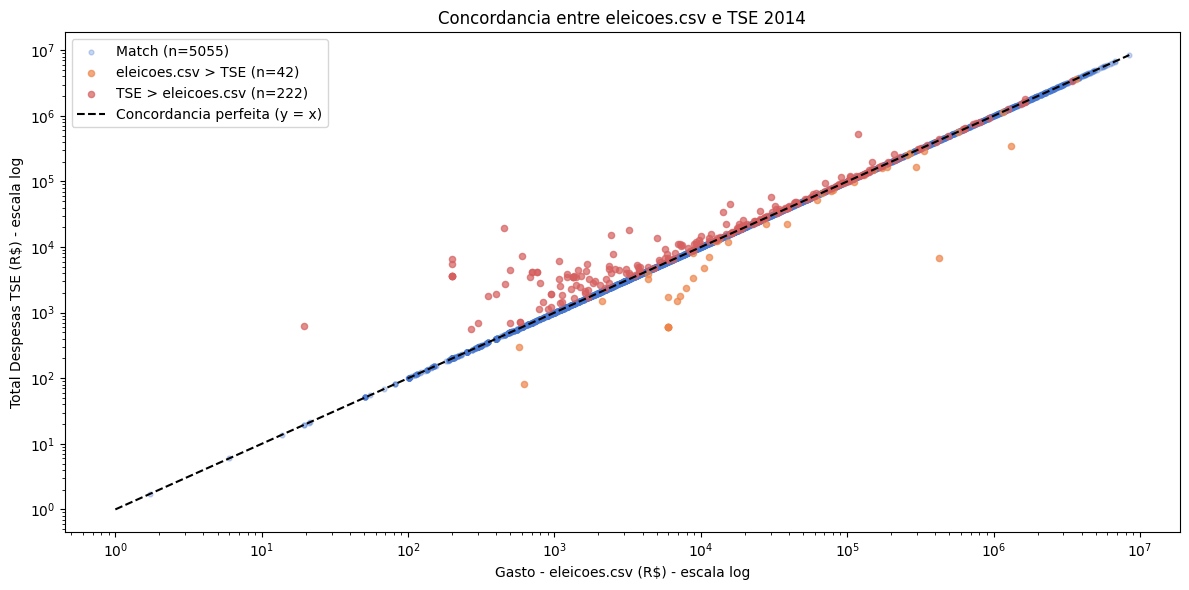

In [54]:
mask_match_plot = comparacao["Diferenca"] < 1
mask_div_el = (comparacao["Diferenca"] >= 1) & (
    comparacao["Gasto"] > comparacao["Total_Despesas_TSE"]
)
mask_div_ts = (comparacao["Diferenca"] >= 1) & (
    comparacao["Total_Despesas_TSE"] > comparacao["Gasto"]
)

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.scatter(
    comparacao.loc[mask_match_plot, "Gasto"] + 1,
    comparacao.loc[mask_match_plot, "Total_Despesas_TSE"] + 1,
    color=CORES[0],
    alpha=0.3,
    s=12,
    label=f"Match (n={mask_match_plot.sum()})",
)
ax.scatter(
    comparacao.loc[mask_div_el, "Gasto"] + 1,
    comparacao.loc[mask_div_el, "Total_Despesas_TSE"] + 1,
    color=CORES[1],
    alpha=0.7,
    s=20,
    label=f"eleicoes.csv > TSE (n={mask_div_el.sum()})",
)
ax.scatter(
    comparacao.loc[mask_div_ts, "Gasto"] + 1,
    comparacao.loc[mask_div_ts, "Total_Despesas_TSE"] + 1,
    color=CORES[3],
    alpha=0.7,
    s=20,
    label=f"TSE > eleicoes.csv (n={mask_div_ts.sum()})",
)

lim = max(comparacao["Gasto"].max(), comparacao["Total_Despesas_TSE"].max()) + 1
ax.plot([1, lim], [1, lim], "k--", label="Concordancia perfeita (y = x)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Gasto - eleicoes.csv (R$) - escala log")
ax.set_ylabel("Total Despesas TSE (R$) - escala log")
ax.set_title("Concordancia entre eleicoes.csv e TSE 2014")
ax.legend()
plt.tight_layout()
plt.savefig("assets/validacao_gasto_tse.png")
plt.show()

**Observações:**
- pontos sobre a diagonal: valores identicos nas duas fontes
- pontos abaixo da diagonal: `eleicoes.csv` registra mais que o TSE
- pontos acima da diagonal: TSE registra mais que `eleicoes.csv`
- a concentracao de pontos sobre a diagonal confirma a consistencia dos dados
- as divergencias sao pontuais e nao comprometem a analise

o gráfico mostra que o merge entre as tabelas faz sentido e é o ano certo, já que o dataset do professor não falava de qual ano era.

#### <font color=slategray> 2.3.4 - Análise dos candidatos divergentes

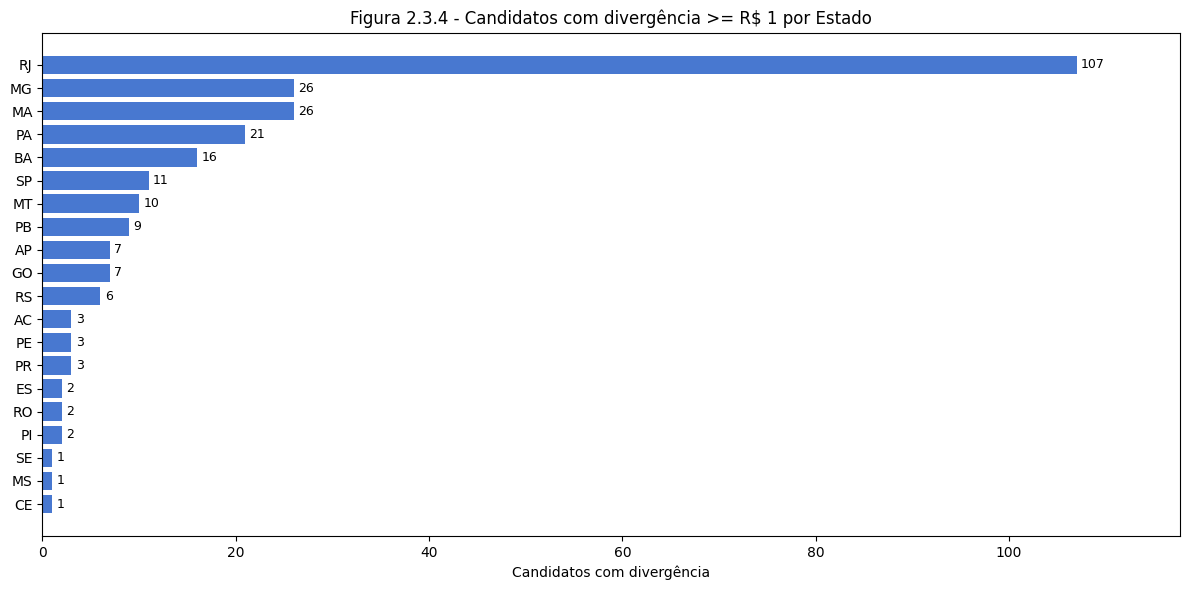

In [55]:
diverge = comparacao[mask_diverge].copy()


contagem = diverge.groupby("Estado").size().sort_values()

fig, ax = plt.subplots(figsize=FIGSIZE)

bars = ax.barh(contagem.index, contagem.values, color=CORES[0])
ax.bar_label(bars, padding=3, fontsize=9)

ax.set_xlabel("Candidatos com divergência")
ax.set_title("Figura 2.3.4 - Candidatos com divergência >= R$ 1 por Estado")
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig("assets/divergentes_por_estado.png")
plt.show()

**Observações:**
- RJ concentra `~40%` das divergências (107 de 264)
- hipótese: o dataset do professor pode ter sido compilado a partir de uma versão anterior da prestação de contas do TSE
- as divergências não comprometem a análise: `Gasto` permanece como medida oficial do gasto declarado por candidato

## <font color=darkblue> 3 - Análise exploratória dos dados

antes de iniciar a análise, registro 3 decisões metodológicas que impactam os gráficos, tabelas e análises desta seção:

- coluna de gasto utilizada: utilizo `Gasto` do dataset do professor em vez de `Total_Despesas_TSE`. o professor não solicitou o enriquecimento e os dados do TSE podem gerar divergências expressivas dependendo do estado, como visto na seção 2.3. onde o RJ(quem diria) tem 107 divergências.
- exclusão de candidatos com gasto zero: removi todos os candidatos com `Gasto = 0`. nenhum candidato eleito teve gasto zero, eles representam uma parcela significativa do dataset e `esta análise é sobre comportamento de gastos`: candidatos que não gastaram nada não fazem parte do público que quero explorar
- ordem de análises: a análise vai ser primeiro com poucas análises do Brasil como um todo e depois vou escolher 3 estados para continuar com as exigencias do trabalho como foi pedido no pdf.

### <font color=steelblue> 3.1 - Visão geral do dataset Brasil

In [56]:
print("Tabela 3.1 — Estatísticas descritivas do dataset das Eleições de 2014")
display(
    eleicoes_enriquecido.describe()
    .drop(columns=["Numero Candidato", "CPF", "Votos"])
    .T.map(lambda x: f"{x:,.2f}")
)

Tabela 3.1 — Estatísticas descritivas do dataset das Eleições de 2014


,count,mean,std,min,25%,50%,75%,max
Gasto,"6,353.00","184,664.82","584,668.80",0.00,880.00,"5,804.26","46,569.29","8,464,594.14"
Qtd_Notas,"6,353.00",114.21,392.73,0.00,2.00,9.00,42.00,"6,413.00"
Total_Despesas_TSE,"5,392.00","217,794.87","628,857.96",0.14,"2,383.75","9,818.42","74,484.67","8,464,594.14"


### <font color=steelblue> 3.2 - Cáculo do bins Brasil

In [57]:
mask_com_gasto = eleicoes_enriquecido["Gasto"] > 0
gastos = eleicoes_enriquecido[mask_com_gasto]["Gasto"]

n_bins = int(np.sqrt(len(gastos)))

largura_linear = (gastos.max() - gastos.min()) / n_bins

resumo_bins = pd.DataFrame(
    {
        "Parâmetro": [
            "Candidatos com gasto > 0",
            "Número de bins (√n)",
            "Gasto mínimo",
            "Gasto máximo",
            "Largura de cada bin (linear)",
        ],
        "Valor": [
            f"{len(gastos):,}",
            f"{n_bins}",
            f"R$ {gastos.min():,.2f}",
            f"R$ {gastos.max():,.2f}",
            f"R$ {largura_linear:,.2f}",
        ],
    }
)

print("Tabela 3.2 - Parâmetros do histograma")
display(resumo_bins.set_index("Parâmetro"))

Tabela 3.2 - Parâmetros do histograma


,Valor
Parâmetro,
Candidatos com gasto > 0,"5,323"
Número de bins (√n),72
Gasto mínimo,R$ 0.72
Gasto máximo,"R$ 8,464,594.14"
Largura de cada bin (linear),"R$ 117,563.80"


**Observações:**
- o número de bins foi utilizado o cálculo ensinado em aula que era a raiz quadrada da quantidade de elementos
- n_bins = 72, ou seja, vou dividir meu intervalo em `72 partes`.
- cada bin vai ter aproximadamente `~R$115,000.00`

### <font color=steelblue> 3.3 - Distribuição do Gasto por Candidato Brasil

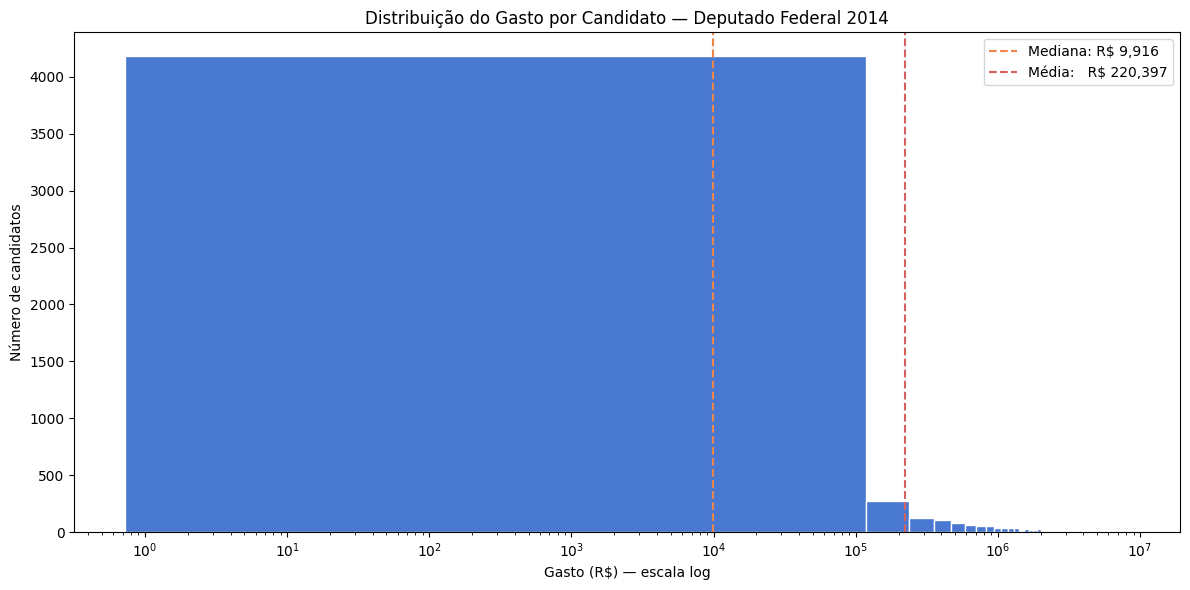

In [58]:
mask_com_gasto = eleicoes_enriquecido["Gasto"] > 0
gastos = eleicoes_enriquecido[mask_com_gasto]["Gasto"]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(gastos, bins=n_bins, color=CORES[0], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Gasto (R$) — escala log")
ax.set_ylabel("Número de candidatos")
ax.set_title("Distribuição do Gasto por Candidato — Deputado Federal 2014")
ax.axvline(
    gastos.median(),
    color=CORES[1],
    linestyle="--",
    label=f"Mediana: R$ {gastos.median():,.0f}",
)
ax.axvline(
    gastos.mean(),
    color=CORES[3],
    linestyle="--",
    label=f"Média:   R$ {gastos.mean():,.0f}",
)
ax.legend()
plt.tight_layout()
plt.savefig("assets/distribuicao_gasto.png")
plt.show()

**Observações:**
- a distribuição é fortemente assimétrica à direita: a maioria dos candidatos gasta pouco, enquanto poucos concentram valores muito altos
- `mediana de R$ 9.916` contra `média de R$ 220.397`: o afastamento entre as duas medidas é sinal claro de assimetria e presença de valores extremos puxando a média para cima
- a cauda direita se estende até R$ 1M+, com poucos candidatos nessa faixa

### <font color=steelblue> 3.4 - Gasto por Estado Brasil

#### <font color=slategray> 3.4.1 - Gasto total por Estado

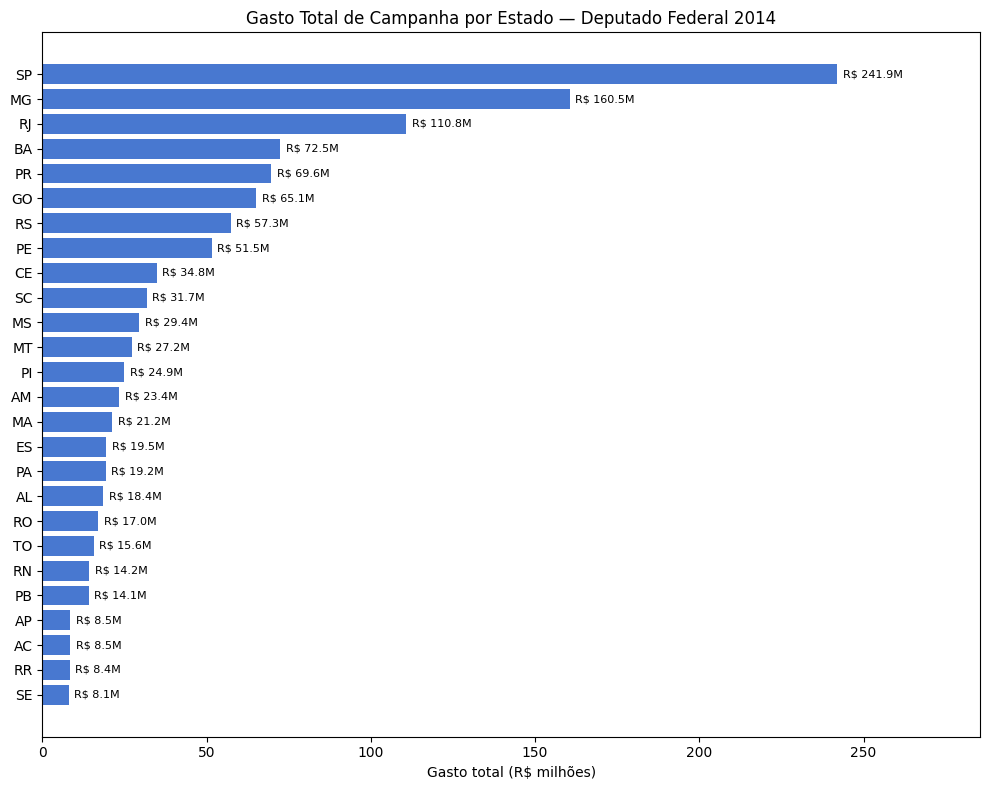

In [59]:
total_estado = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Estado")["Gasto"]
    .sum()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(total_estado.index, total_estado.values / 1e6, color=CORES[0])
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Gasto Total de Campanha por Estado — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4, fontsize=8)
ax.set_xlim(0, total_estado.max() / 1e6 * 1.18)
plt.tight_layout()
plt.savefig("assets/gasto_total_estado.png")
plt.show()

**Observações:**
- SP, MG e RJ concentram os maiores volumes de gasto total


#### <font color=slategray> 3.4.2 - Gasto médio por Estado

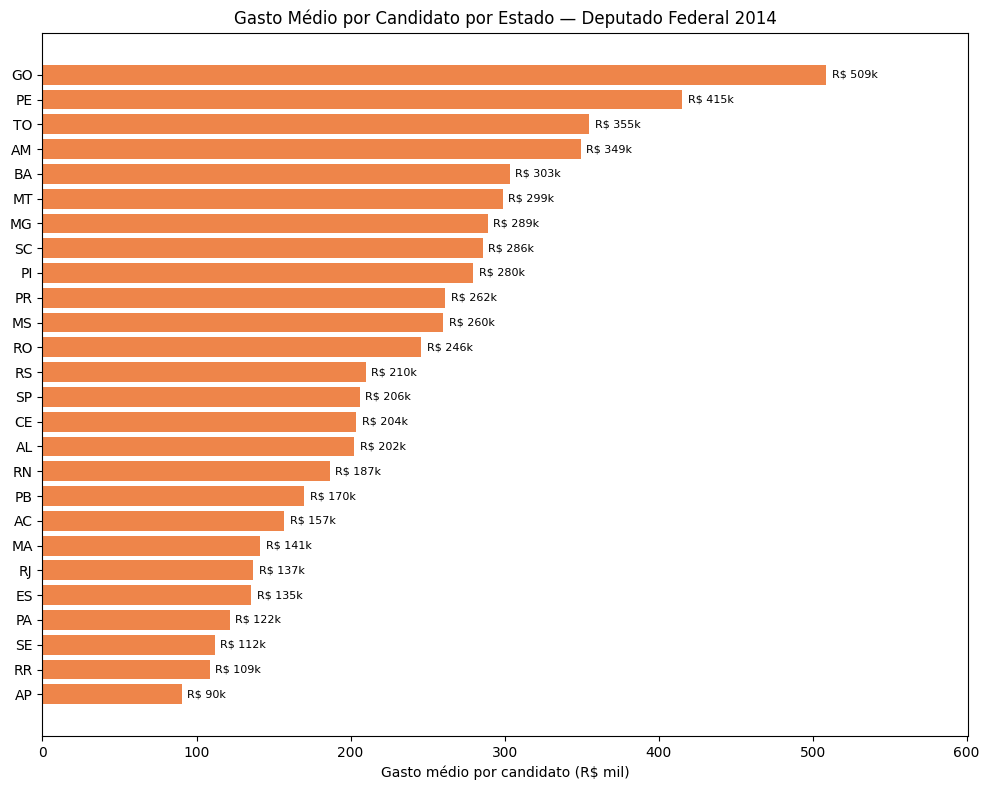

In [60]:
media_estado = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Estado")["Gasto"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(media_estado.index, media_estado.values / 1e3, color=CORES[1])
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Gasto Médio por Candidato por Estado — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4, fontsize=8)
ax.set_xlim(0, media_estado.max() / 1e3 * 1.18)
plt.tight_layout()
plt.savefig("assets/gasto_medio_estado.png")
plt.show()

**Observações:**
- o ranking de média difere do de total: estados menores como GO, TO e AM aparecem no topo, enquanto SP cai para posições intermediárias

### <font color=steelblue> 3.5 - Gasto por Partido (Top 10)

#### <font color=slategray> 3.5.1 - Total por Partido

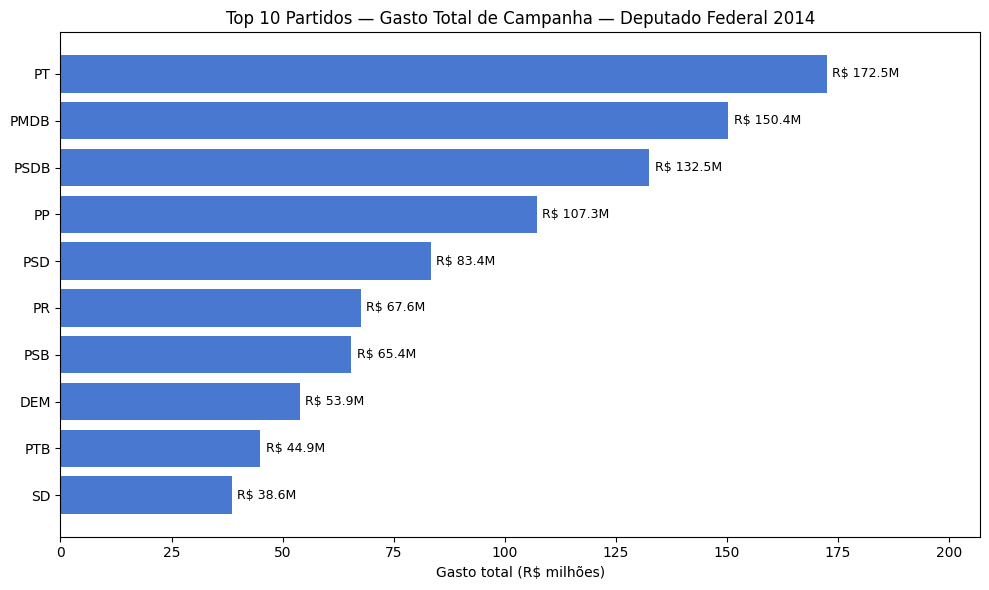

In [61]:
top10_total_partido = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10_total_partido.index, top10_total_partido.values / 1e6, color=CORES[0]
)
ax.set_xlabel("Gasto total (R$ milhões)")
ax.set_title("Top 10 Partidos — Gasto Total de Campanha — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.1fM", padding=4, fontsize=9)
ax.set_xlim(0, top10_total_partido.max() / 1e6 * 1.2)
plt.tight_layout()
plt.savefig("assets/gasto_total_partido.png")
plt.show()

**Observações:**
- PT, PMDB, PSDB e PP lideram o gasto total em 2014
- os quatro partidos tinham representação proporcional no Congresso e acesso ao fundo partidário, o que explica o volume maior de recursos disponíveis por candidatura

#### <font color=slategray> 3.5.2 - Média por Partido

o gasto médio por candidato revela quais partidos investem mais por cabeça. um partido pequeno que não apareceu no gráfico anterior pode entrar nesse por concentrar mais recursos em cada candidatura individual.

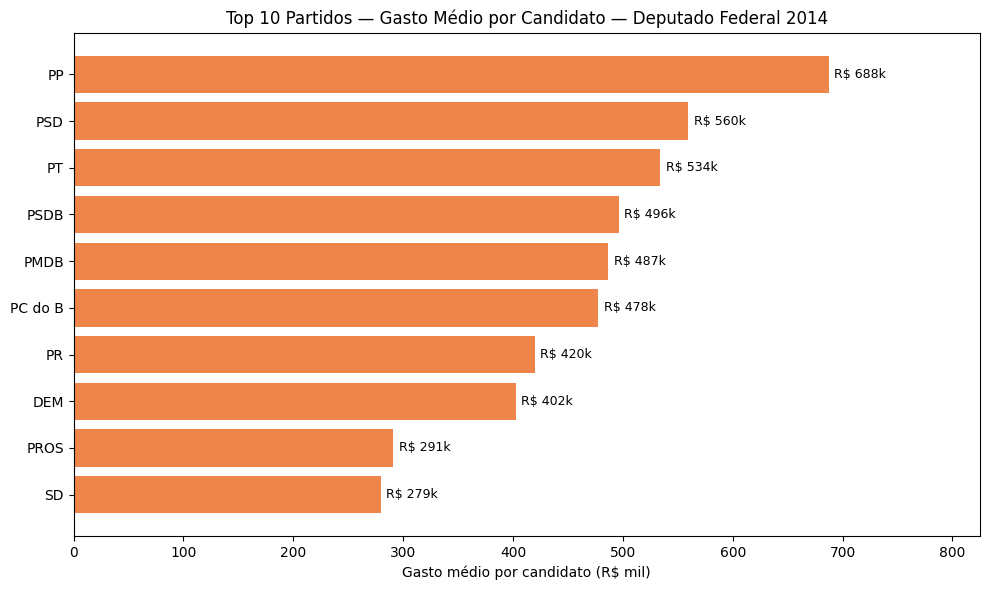

In [62]:
top10_media_partido = (
    eleicoes_enriquecido[eleicoes_enriquecido["Gasto"] > 0]
    .groupby("Partido")["Gasto"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10_media_partido.index, top10_media_partido.values / 1e3, color=CORES[1]
)
ax.set_xlabel("Gasto médio por candidato (R$ mil)")
ax.set_title("Top 10 Partidos — Gasto Médio por Candidato — Deputado Federal 2014")
ax.bar_label(bars, fmt="R$ %.0fk", padding=4, fontsize=9)
ax.set_xlim(0, top10_media_partido.max() / 1e3 * 1.2)
plt.tight_layout()
plt.savefig("assets/gasto_medio_partido.png")
plt.show()

**Observações:**
- partidos com poucos candidatos mas gasto alto por candidatura podem ter média elevada sem aparecer no ranking de total
- o indicador revela concentração de recursos por candidatura em vez de distribuição ampla

### <font color=steelblue> 3.6 - Gasto vs Votos por Situação Eleitoral

comparo gasto e votos de cada candidato colorindo por resultado eleitoral. linhas de referência verticais marcam o gasto mínimo, mediana, média e máximo dos eleitos. linhas horizontais marcam o mínimo de votos para eleição por média e por quociente partidário.

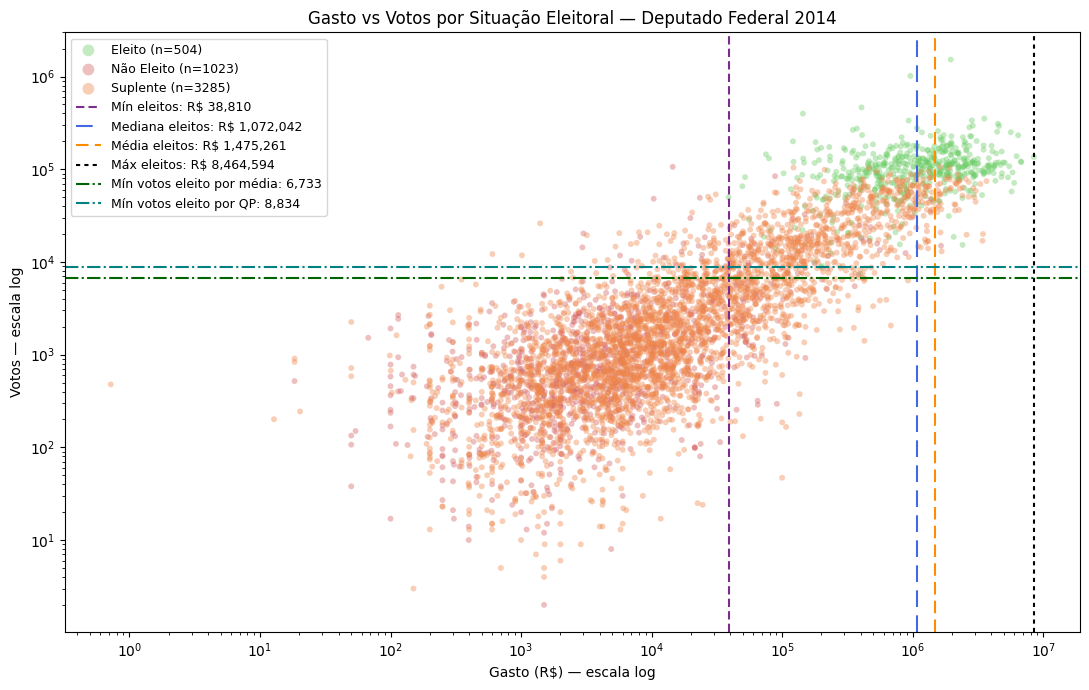

Tabela 3.6 - Gasto e Votos por Resultado Eleitoral


,N,Gasto Médio,Gasto Mediana,Gasto Mín,Gasto Máx,Votos Médios,Votos Mediana
Eleito,504,"R$ 1,475,261","R$ 1,072,042","R$ 38,810","R$ 8,464,594","113,917","102,866"
Suplente,"3,285","R$ 119,472","R$ 11,932",R$ 1,"R$ 3,672,371","8,211","1,722"
Não Eleito,"1,023","R$ 23,316","R$ 3,450",R$ 18,"R$ 1,646,192","2,454",736
Total,"4,812","R$ 241,033","R$ 11,840",R$ 1,"R$ 8,464,594","18,058","1,775"


In [63]:
plot_gasto_vs_votos(eleicoes_enriquecido)
tabela_gasto_vs_votos(eleicoes_enriquecido, "Tabela 3.6 - Gasto e Votos por Resultado Eleitoral")

**Observações:**
- candidatos eleitos concentram no quadrante superior direito: mais gasto e mais votos
- existe uma faixa de gasto mínimo dos eleitos: candidatos abaixo de R$ 38k raramente foram eleitos
- a correlação entre gasto e votos é positiva mas não determinística: há candidatos com alto gasto e poucos votos e vice versa
- suplentes e não eleitos se misturam bastante na faixa intermediária de gasto

### <font color=steelblue> 3.7 - Análise exploratória Goiás